**MILESTONE 1**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("/content/Agriyeild dataset.csv")
df.head()

,State,Crop,Soil_Type,Fertilizer,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
0,Karnataka,Soybean,Loamy,DAP,96,41,51,123,31.06,1899,6.82,2003
1,Odisha,Cotton,Red Soil,Urea,29,36,112,247,33.97,1002,6.41,2002
2,Punjab,Groundnut,Red Soil,Compost,37,38,177,142,24.21,1465,7.06,2015
3,Gujarat,Wheat,Red Soil,Compost,58,77,129,227,30.85,2273,5.93,2022
4,Andhra Pradesh,Cotton,Clay,Organic,108,61,63,263,37.81,1497,6.24,2017


In [10]:
df.describe()

,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,73.438000,61.282667,102.112667,176.806000,28.148547,7881.892667,6.766347,2012.090000
std,37.756932,33.257422,54.362863,73.776182,5.783160,20073.333665,0.724898,7.393218
min,10.000000,5.000000,10.000000,50.000000,18.020000,502.000000,5.500000,2000.000000
25%,41.000000,33.000000,56.000000,113.000000,23.132500,1202.750000,6.120000,2005.000000
50%,70.000000,61.000000,100.000000,176.000000,28.490000,1673.500000,6.795000,2012.000000
75%,106.000000,91.000000,149.000000,242.000000,33.180000,2571.750000,7.400000,2019.000000
max,139.000000,119.000000,199.000000,299.000000,37.960000,89946.000000,8.000000,2024.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State              1500 non-null   object 
 1   Crop               1500 non-null   object 
 2   Soil_Type          1500 non-null   object 
 3   Fertilizer         1500 non-null   object 
 4   N                  1500 non-null   int64  
 5   P                  1500 non-null   int64  
 6   K                  1500 non-null   int64  
 7   Rainfall_mm        1500 non-null   int64  
 8   Temperature_C      1500 non-null   float64
 9   Yield_kg_per_acre  1500 non-null   int64  
 10  Soil_pH            1500 non-null   float64
 11  Year               1500 non-null   int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 140.8+ KB


In [14]:
df.shape

(1500, 12)

In [15]:
df.columns

Index(['State', 'Crop', 'Soil_Type', 'Fertilizer', 'N', 'P', 'K',
       'Rainfall_mm', 'Temperature_C', 'Yield_kg_per_acre', 'Soil_pH', 'Year'],
      dtype='object')

In [16]:
df.isnull().sum()

,0
State,0
Crop,0
Soil_Type,0
Fertilizer,0
N,0
P,0
K,0
Rainfall_mm,0
Temperature_C,0
Yield_kg_per_acre,0


In [19]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed successfully.")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


**MILESTONE 2**

array([[<Axes: title={'center': 'N'}>, <Axes: title={'center': 'P'}>,
        <Axes: title={'center': 'K'}>],
       [<Axes: title={'center': 'Rainfall_mm'}>,
        <Axes: title={'center': 'Temperature_C'}>,
        <Axes: title={'center': 'Yield_kg_per_acre'}>],
       [<Axes: title={'center': 'Soil_pH'}>,
        <Axes: title={'center': 'Year'}>, <Axes: >]], dtype=object)

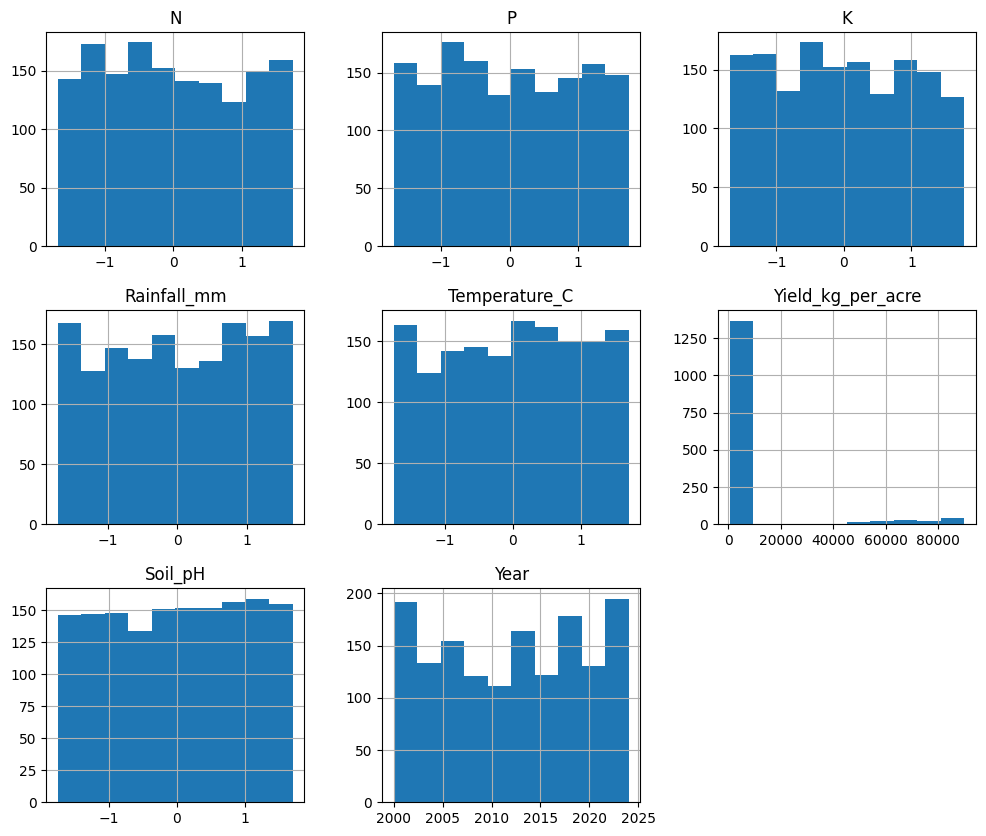

In [20]:
df.hist(figsize=(12,10))

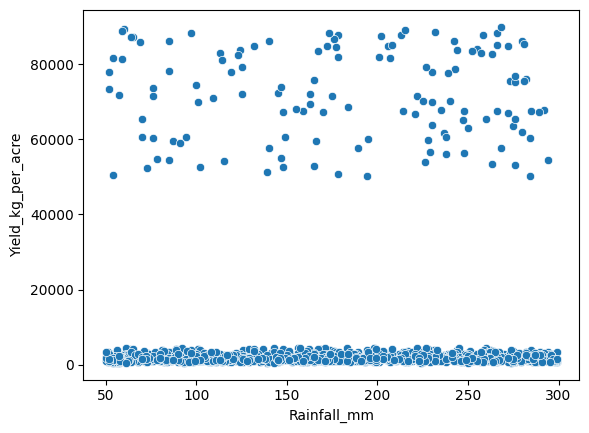

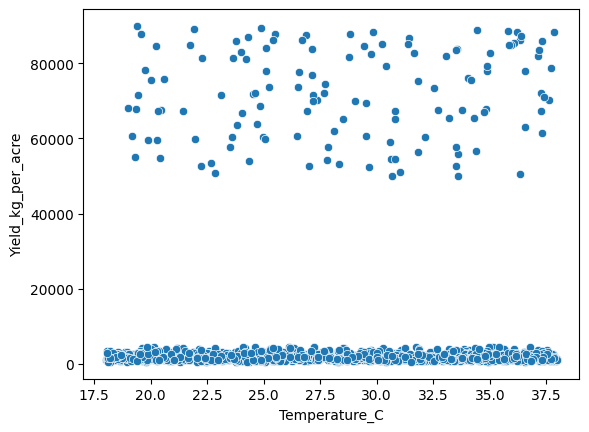

In [5]:

sns.scatterplot(x='Rainfall_mm', y='Yield_kg_per_acre', data=df)
plt.show()

sns.scatterplot(x='Temperature_C', y='Yield_kg_per_acre', data=df)
plt.show()

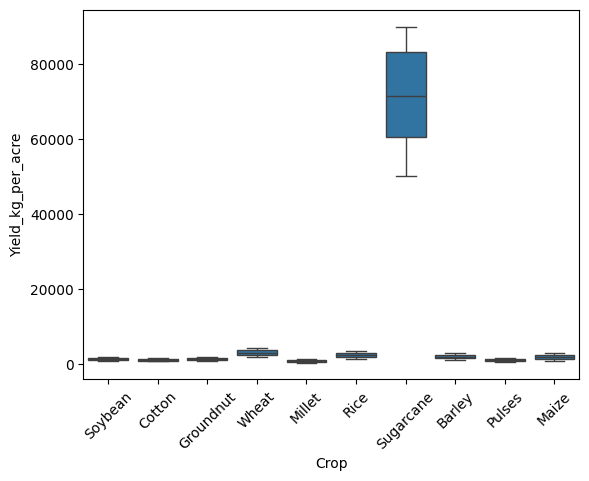

In [6]:
sns.boxplot(x='Crop', y='Yield_kg_per_acre', data=df)
plt.xticks(rotation=45)
plt.show()

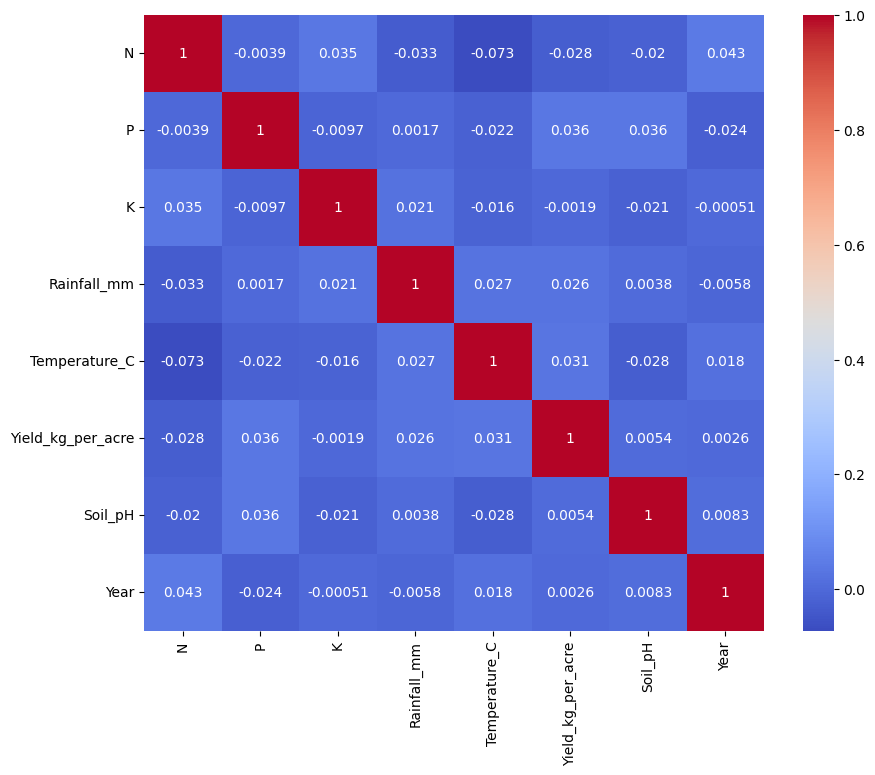

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

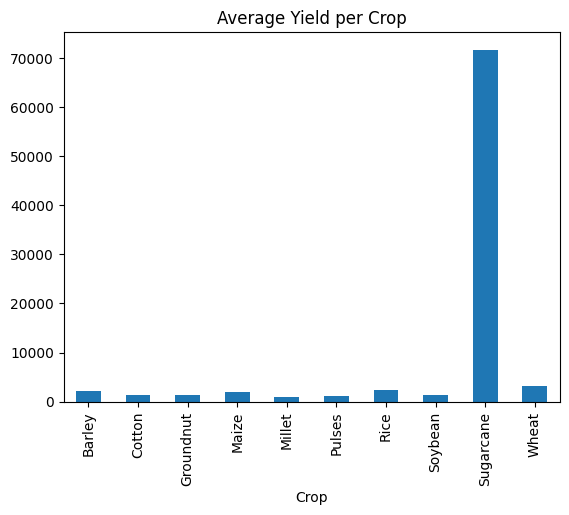

In [9]:
df.groupby('Crop')['Yield_kg_per_acre'].mean().plot(kind='bar')
plt.title("Average Yield per Crop")
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['State'] = le.fit_transform(df['State'])
df['Crop'] = le.fit_transform(df['Crop'])
df['Soil_Type'] = le.fit_transform(df['Soil_Type'])
df['Fertilizer'] = le.fit_transform(df['Fertilizer'])

In [11]:
df['NPK_sum'] = df['N'] + df['P'] + df['K']
df['temp_rainfall'] = df['Temperature_C'] * df['Rainfall_mm']
df['ph_temp'] = df['Soil_pH'] * df['Temperature_C']